##CELDA 1
Carga, limpieza y dataframe unificado

In [ ]:
#============================================================
# CELDA 1 — CARGA, LIMPIEZA Y DATAFRAME UNIFICADO
#============================================================
from google.colab import files
import pandas as pd
import numpy as np

print("Selecciona los 9 archivos CSV:")
uploaded = files.upload()

def cargar_csv(archivo):
    for enc in ["utf-8", "utf-8-sig", "latin1", "cp1252"]:
        for sep in [",", ";", "\t"]:
            try:
                df = pd.read_csv(archivo, encoding=enc, sep=sep)
                if "Fecha" not in df.columns or "Valor" not in df.columns:
                    continue
                f1 = pd.to_datetime(df["Fecha"], errors="coerce", dayfirst=False)
                f2 = pd.to_datetime(df["Fecha"], errors="coerce", dayfirst=True)
                df["Fecha"] = f2 if f2.isna().sum() < f1.isna().sum() else f1
                df["Valor"] = pd.to_numeric(df["Valor"], errors="coerce")
                return df
            except Exception:
                continue
    print(f" ERROR leyendo: {archivo}")
    return None

dfs_raw = {a.replace(".csv", ""): cargar_csv(a) for a in uploaded.keys()}

def asignar_alias(nombre):
    n = nombre.upper()
    if "TARGET" in n:                          return "TARGET"
    if "CHIMA" in n:                           return "CHIMA_PRECIP"
    if "MOMIL" in n:                           return "MOMIL_PRECIP"
    if "DOCTRINA" in n:                        return "DOCTRINA_PRECIP"
    if "PALMACENTRAL" in n and "NIVEL" in n:   return "PALMA_NIV"
    if "COTOCA" in n and "QMD" in n:           return "COTOCA_QMD"
    if "COTOCA" in n and "NIVEL" in n:         return "COTOCA_NIV"
    if "SABANA" in n and "QMD" in n:           return "SABANA_QMD"
    if "SABANA" in n and "NIVEL" in n:         return "SABANA_NIV"
    return nombre

print("\nAliases detectados:")
for nombre in dfs_raw:
    estado = "✅" if dfs_raw[nombre] is not None else "❌ FALLO"
    print(f"  '{nombre}' -> '{asignar_alias(nombre)}' [{estado}]")

dfs_limpios = {}
for nombre, df in dfs_raw.items():
    alias = asignar_alias(nombre)
    if df is None:
        print(f"  ⚠️ SALTANDO '{nombre}' -> no se pudo leer"); continue
    if "Fecha" not in df.columns or "Valor" not in df.columns:
        print(f"  ⚠️ SALTANDO '{nombre}' -> columnas: {list(df.columns)}"); continue
    temp = df[["Fecha", "Valor"]].dropna(subset=["Fecha"]).copy()
    temp = temp.rename(columns={"Valor": alias})
    temp["Fecha"] = temp["Fecha"].dt.normalize()
    temp = temp.drop_duplicates(subset=["Fecha"])
    dfs_limpios[alias] = temp

print(f"\nArchivos cargados ({len(dfs_limpios)}): {list(dfs_limpios.keys())}")
if len(dfs_limpios) == 0:
    raise ValueError("Ningun archivo se cargo correctamente.")

df_merge = None
for alias, df in dfs_limpios.items():
    df_merge = df if df_merge is None else df_merge.merge(df, on="Fecha", how="outer")
df_merge = df_merge.sort_values("Fecha").reset_index(drop=True)

print(f"df_merge shape: {df_merge.shape}")
print(f"Columnas: {list(df_merge.columns)}")
print(f"Rango: {df_merge['Fecha'].min().date()} -> {df_merge['Fecha'].max().date()}")

import matplotlib.pyplot as plt
grupos = {
    "Caudal QMD (m³/s)": [c for c in df_merge.columns if "QMD"    in c and "LAG" not in c],
    "Nivel (m)":          [c for c in df_merge.columns if "NIV"    in c and "LAG" not in c],
    "Precipitación (mm)": [c for c in df_merge.columns if "PRECIP" in c and "LAG" not in c],
}
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Distribución por tipo de variable (datos originales sin LAG)", fontsize=13)
for ax, (titulo, cols) in zip(axes, grupos.items()):
    if len(cols) == 0:
        ax.set_title(f"{titulo}\n(sin datos)"); ax.axis("off"); continue
    datos = [df_merge[c].dropna().values for c in cols]
    bp = ax.boxplot(datos, patch_artist=True, notch=False,
                    medianprops=dict(color="black", linewidth=2))
    colores = {"QMD": "steelblue", "NIV": "seagreen", "PRECIP": "darkorange"}
    color = next((v for k, v in colores.items() if k in titulo), "gray")
    for patch in bp["boxes"]:
        patch.set_facecolor(color); patch.set_alpha(0.6)
    ax.set_xticks(range(1, len(cols) + 1))
    ax.set_xticklabels(cols, rotation=30, ha="right", fontsize=9)
    ax.set_title(titulo, fontsize=11)
    ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

for titulo, cols in grupos.items():
    if len(cols) == 0: continue
    print(f"\n{'='*55}\n{titulo}\n{'='*55}")
    print(df_merge[cols].describe().round(2).to_string())

##CELDA 2 - EDA : FALTANTES, LAG1 Y CORRELACION PAIRWISE

In [ ]:
#============================================================
# CELDA 2 — EDA: FALTANTES, LAG1 Y CORRELACION PAIRWISE
#============================================================
import matplotlib.pyplot as plt
import numpy as np, pandas as pd

try: df_merge
except NameError: raise NameError("Ejecuta la Celda 1 primero.")

# Heatmap de datos faltantes
df_heat  = df_merge.set_index("Fecha").sort_index()
faltante = df_heat.isna().astype(int)
fechas_idx = faltante.index
tick_pos, tick_lbl = [], []
for a in sorted(fechas_idx.year.unique()):
    pos = np.searchsorted(fechas_idx, f"{a}-01-01")
    if pos < len(fechas_idx):
        tick_pos.append(pos); tick_lbl.append(str(a))

fig, ax = plt.subplots(figsize=(16, 5))
im = ax.imshow(faltante.T, aspect="auto", interpolation="none", cmap="plasma")
plt.colorbar(im, ax=ax, label="1 = dato faltante")
ax.set_yticks(range(len(faltante.columns)))
ax.set_yticklabels(faltante.columns, fontsize=9)
ax.set_xticks(tick_pos); ax.set_xticklabels(tick_lbl, rotation=45, ha="right")
ax.set_title("Heatmap de datos faltantes por estacion")
ax.set_xlabel("Año"); plt.tight_layout(); plt.show()

# LAG1 para QMD y Niveles (precipitacion sin rezago: efecto mismo dia)
df_lag = df_merge.copy()
for col in ["COTOCA_QMD", "SABANA_QMD", "COTOCA_NIV", "SABANA_NIV"]:
    if col in df_lag.columns:
        df_lag[f"{col}_LAG1"] = df_lag[col].shift(1)

# Correlacion pairwise (PALMA_NIV excluida: leakage del propio sitio TARGET)
drop_corr = [c for c in ["Fecha", "PALMA_NIV"] if c in df_lag.columns]
corr = df_lag.drop(columns=drop_corr).corr()
fig, ax = plt.subplots(figsize=(14, 11))
im2 = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im2, ax=ax, label="Pearson r")
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=6.5)
ax.set_title("Correlacion pairwise con LAG1 (PALMA_NIV excluida)")
plt.tight_layout(); plt.show()

print("\nCorrelacion con TARGET (descendente):")
print(corr["TARGET"].drop("TARGET").sort_values(ascending=False).to_string())

##CELDA 3
GRIDSEARCH CV

In [ ]:
#============================================================
# CELDA 3 — GRIDSEARCH RF
# (eliminada curva de validacion 3A)
#============================================================
from sklearn.ensemble        import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import numpy as np, pandas as pd

try: df_lag
except NameError: raise NameError("Ejecuta la Celda 2 primero.")

TARGET_COL  = "TARGET"
PREDICTORES = [p for p in [
    "COTOCA_QMD", "COTOCA_QMD_LAG1", "SABANA_QMD", "SABANA_QMD_LAG1",
    "COTOCA_NIV", "COTOCA_NIV_LAG1", "SABANA_NIV", "SABANA_NIV_LAG1",
    "CHIMA_PRECIP", "MOMIL_PRECIP", "DOCTRINA_PRECIP",
] if p in df_lag.columns]

# Dataset listwise + split cronologico 80/20
# El pasado entrena, el futuro evalua — nunca mezclar fechas
df_ml = (df_lag[[TARGET_COL] + PREDICTORES + ["Fecha"]]
         .dropna().sort_values("Fecha").reset_index(drop=True))
corte       = int(len(df_ml) * 0.8)
train, test = df_ml.iloc[:corte], df_ml.iloc[corte:]
X_train, y_train = train[PREDICTORES], train[TARGET_COL]
X_test,  y_test  = test[PREDICTORES],  test[TARGET_COL]
print(f"Dataset: {len(df_ml)} filas | TRAIN {len(train)} | TEST {len(test)}")

# CV con gap de 14 dias: evita que el modelo copie el ultimo valor
# de entrenamiento (alta autocorrelacion en series hidrologicas)
tscv = TimeSeriesSplit(n_splits=5, gap=14)

param_grid = {
    "n_estimators":     [100, 200, 300, 500],
    "max_depth":        [5, 10, 15, 20, 30],
    "min_samples_leaf": [2, 3, 5, 10, 15, 20, 30],
}
gs = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1),
                  param_grid, cv=tscv, scoring="r2", n_jobs=-1, verbose=1)
gs.fit(X_train, y_train)
BEST_PARAMS = gs.best_params_
print(f"\nBEST_PARAMS RF: {BEST_PARAMS}")
print(f"R² CV (train):  {gs.best_score_:.4f}")

Dataset: 5541 filas | TRAIN 4432 | TEST 1109
Fitting 5 folds for each of 140 candidates, totalling 700 fits

BEST_PARAMS RF: {'max_depth': 10, 'min_samples_leaf': 2, 'n_estimators': 100}
R² CV (train):  0.9532


##CELDA 4

IMPORTANCIA RF CALCULADA EN TRAIN:


,Variable,Importancia_RF,Importancia_norm,Acum
0,COTOCA_NIV,0.932103,0.932103,0.932103
1,COTOCA_QMD,0.035894,0.035894,0.967997
2,SABANA_QMD,0.015853,0.015853,0.983850
3,SABANA_NIV,0.008817,0.008817,0.992667
4,SABANA_QMD_LAG1,0.002600,0.002600,0.995267
5,SABANA_NIV_LAG1,0.002082,0.002082,0.997349
6,COTOCA_NIV_LAG1,0.001110,0.001110,0.998459
7,COTOCA_QMD_LAG1,0.001043,0.001043,0.999502
8,MOMIL_PRECIP,0.000173,0.000173,0.999676
9,CHIMA_PRECIP,0.000164,0.000164,0.999840



Variables finales RF (3 vars, umbral 98%): ['COTOCA_NIV', 'COTOCA_QMD', 'SABANA_QMD']

PERMUTATION IMPORTANCE RF EN TEST:


,Variable,Perm_importance_TEST,Perm_std_TEST
0,COTOCA_NIV,1.259311,0.042884
1,SABANA_QMD,0.072130,0.005230
2,COTOCA_QMD,0.012292,0.001415



MÉTRICAS RF FINAL
TRAIN: R²=0.9917 | NSE=0.9917 | RMSE=14.81 | MAE=8.64 | PBIAS=0.00%
TEST : R²=0.9064 | NSE=0.9064 | RMSE=48.90 | MAE=29.11 | PBIAS=2.59%
GAP R²: 0.0853


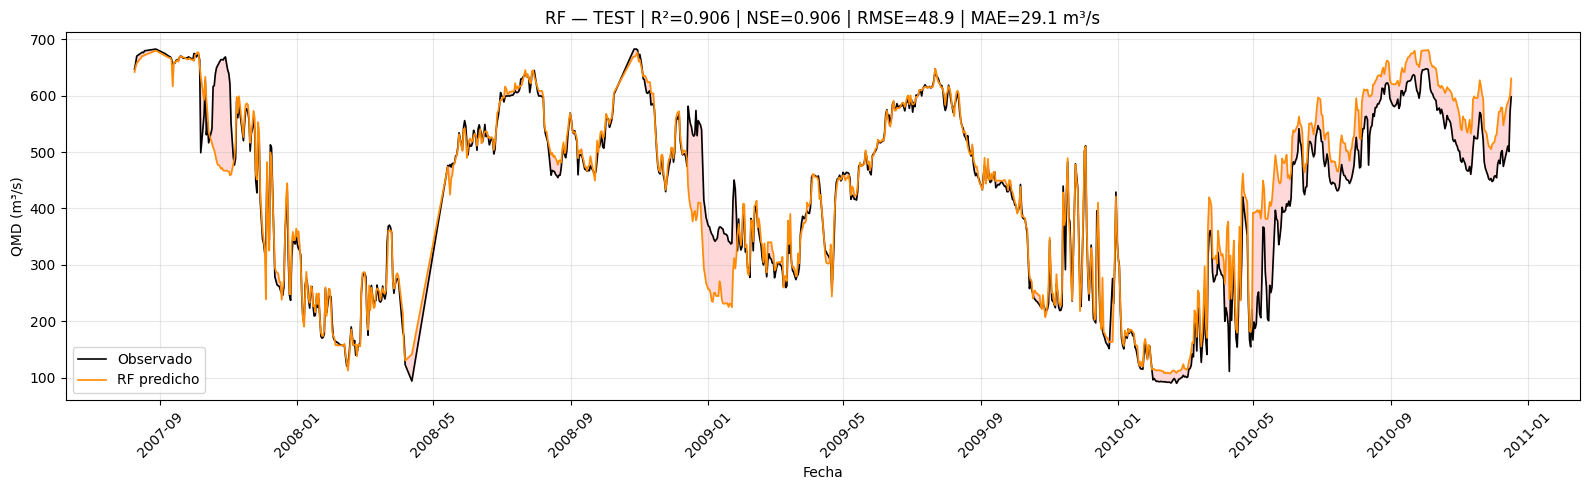

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✔ RF_evaluacion.xlsx exportado

Sube los archivos: COTOCA_NIV.csv, COTOCA_QMD.csv, SABANA_QMD.csv


In [ ]:
#============================================================
# CELDA 4 — RF FINAL + EXPORTACION
# Evaluacion (TRAIN/TEST) y Prediccion (2011-2025)
#============================================================
!pip install openpyxl -q
from sklearn.ensemble    import RandomForestRegressor
from sklearn.inspection  import permutation_importance
from sklearn.metrics     import r2_score, mean_squared_error, mean_absolute_error
from google.colab        import files
import numpy as np, pandas as pd, matplotlib.pyplot as plt, io, re

try: X_train; y_train; X_test; y_test; PREDICTORES; BEST_PARAMS; train; test
except NameError: raise NameError("Ejecuta las Celdas 1-3 primero.")

# ── Funciones metricas ───────────────────────────────────────────────────────
def nse(obs, pred):
    obs, pred = np.asarray(obs), np.asarray(pred)
    return 1 - np.sum((obs-pred)**2) / np.sum((obs-obs.mean())**2)

def pbias(obs, pred):
    obs, pred = np.asarray(obs), np.asarray(pred)
    return 100 * np.sum(pred-obs) / np.sum(obs)

def metricas(obs, pred, label):
    r2_ = r2_score(obs, pred)
    print(f"{label}: R²={r2_:.4f} | NSE={nse(obs,pred):.4f} | "
          f"RMSE={np.sqrt(mean_squared_error(obs,pred)):.2f} | "
          f"MAE={mean_absolute_error(obs,pred):.2f} | "
          f"PBIAS={pbias(obs,pred):.2f}%")
    return r2_

# ── Funciones auxiliares de carga e imputacion ───────────────────────────────
def leer_csv(nombre, contenido):
    df = None
    for enc in ["utf-8", "utf-8-sig", "latin1", "cp1252"]:
        for sep in [None, ",", ";", "\t"]:
            try:
                tmp = pd.read_csv(io.BytesIO(contenido), encoding=enc,
                                  sep=sep, engine="python")
                if tmp.shape[1] >= 2: df = tmp.copy(); break
            except: pass
        if df is not None: break
    df.columns = [str(c).strip() for c in df.columns]
    col_f = next((c for c in df.columns if "fecha" in c.lower()
                  or "date" in c.lower()), df.columns[0])
    col_v = next((c for c in df.columns if any(k in c.lower()
                  for k in ["valor","caudal","nivel","flow"])), df.columns[1])
    df = df[[col_f, col_v]].rename(columns={col_f:"Fecha", col_v:"Valor"})
    s  = df["Fecha"].astype(str).str.strip()\
           .str.replace("\ufeff","",regex=False).str.replace("T"," ",regex=False)
    f1 = pd.to_datetime(s, errors="coerce", dayfirst=False)
    f2 = pd.to_datetime(s, errors="coerce", dayfirst=True)
    df["Fecha"] = f2 if f2.isna().sum() < f1.isna().sum() else f1
    df["Valor"] = pd.to_numeric(df["Valor"], errors="coerce")
    df = df.dropna().copy()
    df["Fecha"] = df["Fecha"].dt.normalize()
    return df.groupby("Fecha", as_index=False)["Valor"].mean()

def imputar(s, limite=7):
    # Spline cubico para huecos cortos; lineal para los restantes
    s    = s.copy()
    s_sp = s.interpolate(method="spline", order=3,
                         limit=limite, limit_direction="both")
    s_li = s.interpolate(method="linear", limit_direction="both")
    s[s.isna()] = s_sp[s.isna()].fillna(s_li[s.isna()])
    return s

# ── 1. Importancia interna RF en TRAIN ──────────────────────────────────────
rf_sel = RandomForestRegressor(**BEST_PARAMS, random_state=42, n_jobs=-1)
rf_sel.fit(X_train, y_train)

imp_rf = (pd.DataFrame({"Variable": PREDICTORES,
                         "Importancia_RF": rf_sel.feature_importances_})
          .sort_values("Importancia_RF", ascending=False).reset_index(drop=True))
imp_rf["Importancia_norm"] = imp_rf["Importancia_RF"] / imp_rf["Importancia_RF"].sum()
imp_rf["Acum"] = imp_rf["Importancia_norm"].cumsum()
print("IMPORTANCIA RF CALCULADA EN TRAIN:"); display(imp_rf)

# ── 2. Seleccion con umbral 98% ──────────────────────────────────────────────
# searchsorted: encuentra donde el acumulado cruza 0.98 por primera vez
# +1 convierte indice (base 0) en cantidad de variables a tomar
# max(...,3) garantiza minimo 3 variables siempre
UMBRAL_RF = 0.98
n_rf    = int(np.searchsorted(imp_rf["Acum"].values, UMBRAL_RF)) + 1
n_rf    = max(n_rf, 3)
VARS_RF = imp_rf["Variable"].head(n_rf).tolist()
print(f"\nVariables finales RF ({n_rf} vars, umbral {UMBRAL_RF*100:.0f}%): {VARS_RF}")

# ── 3. Modelo final RF (BEST_PARAMS + VARS_RF + solo TRAIN) ─────────────────
rf_final = RandomForestRegressor(**BEST_PARAMS, random_state=42, n_jobs=-1)
rf_final.fit(X_train[VARS_RF], y_train)
yp_train_rf = rf_final.predict(X_train[VARS_RF])
yp_test_rf  = rf_final.predict(X_test[VARS_RF])

# ── 4. Permutation importance en TEST ────────────────────────────────────────
# Mide cuanto cae el R² al permutar cada variable en datos no vistos (TEST)
perm_rf = permutation_importance(
    rf_final, X_test[VARS_RF], y_test,
    n_repeats=30, random_state=42, scoring="r2", n_jobs=-1)
perm_rf_df = (pd.DataFrame({
    "Variable":             VARS_RF,
    "Perm_importance_TEST": perm_rf.importances_mean,
    "Perm_std_TEST":        perm_rf.importances_std
}).sort_values("Perm_importance_TEST", ascending=False).reset_index(drop=True))
print("\nPERMUTATION IMPORTANCE RF EN TEST:"); display(perm_rf_df)

# ── 5. Metricas TRAIN / TEST ──────────────────────────────────────────────────
print("\nMÉTRICAS RF FINAL")
r2_tr_rf = metricas(y_train, yp_train_rf, "TRAIN")
r2_te_rf = metricas(y_test,  yp_test_rf,  "TEST ")
print(f"GAP R²: {r2_tr_rf - r2_te_rf:.4f}")

# ── 6. Grafico TEST ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(test["Fecha"], y_test.values,  "k",           lw=1.2, label="Observado")
ax.plot(test["Fecha"], yp_test_rf, color="darkorange", lw=1.2, label="RF predicho")
ax.fill_between(test["Fecha"], y_test.values, yp_test_rf, color="red", alpha=0.15)
ax.set_title(f"RF — TEST | R²={r2_te_rf:.3f} | NSE={nse(y_test,yp_test_rf):.3f} | "
             f"RMSE={np.sqrt(mean_squared_error(y_test,yp_test_rf)):.1f} | "
             f"MAE={mean_absolute_error(y_test,yp_test_rf):.1f} m³/s")
ax.set_xlabel("Fecha"); ax.set_ylabel("QMD (m³/s)")
ax.legend(); ax.grid(True, alpha=0.3); ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

# ── 7. Excel RF_evaluacion.xlsx (TRAIN + TEST) ───────────────────────────────
df_eval_rf = pd.concat([
    pd.DataFrame({"Fecha": train["Fecha"].values, "Grupo": "TRAIN",
                  "Observado": y_train.values, "Predicho": yp_train_rf,
                  "Error": yp_train_rf - y_train.values}),
    pd.DataFrame({"Fecha": test["Fecha"].values,  "Grupo": "TEST",
                  "Observado": y_test.values,  "Predicho": yp_test_rf,
                  "Error": yp_test_rf - y_test.values})
], ignore_index=True)
df_eval_rf.to_excel("RF_evaluacion.xlsx", index=False)
files.download("RF_evaluacion.xlsx")
print("✔ RF_evaluacion.xlsx exportado")

# ── 8. Subir CSVs periodo 2011-2025 ──────────────────────────────────────────
VARS_BASE_RF = sorted(set(v.replace("_LAG1","") for v in VARS_RF))
print(f"\nSube los archivos: {', '.join(v+'.csv' for v in VARS_BASE_RF)}")
subidos = files.upload()
subidos_limpios = {
    re.sub(r"\s*\(\d+\)\s*$","",
           n.replace(".csv","").replace(".CSV","")).strip(): c
    for n, c in subidos.items()}

# ── 9. Armar dataframe diario + imputacion ───────────────────────────────────
dfs_rf = {v: leer_csv(v, subidos_limpios[v]).rename(columns={"Valor": v})
          for v in VARS_BASE_RF}
rango_rf = pd.date_range(min(d["Fecha"].min() for d in dfs_rf.values()),
                          max(d["Fecha"].max() for d in dfs_rf.values()), freq="D")
print(f"Rango: {rango_rf[0].date()} → {rango_rf[-1].date()} ({len(rango_rf)} días)")

df_new_rf = pd.DataFrame({"Fecha": rango_rf})
for v, d in dfs_rf.items():
    s = d.set_index("Fecha")[v].reindex(rango_rf)
    print(f"{v:<20} huecos: {s.isna().sum()}")
    df_new_rf[v] = imputar(s).values

for v in VARS_RF:
    if v.endswith("_LAG1"):
        df_new_rf[v] = df_new_rf[v.replace("_LAG1","")].shift(1)

df_pred_rf = df_new_rf.dropna(subset=VARS_RF).reset_index(drop=True)
print(f"Días predichos: {len(df_pred_rf)} / {len(df_new_rf)}")

# ── 10. Prediccion 2011-2025 ─────────────────────────────────────────────────
df_pred_rf["QMD_RF_PREDICHO"] = rf_final.predict(df_pred_rf[VARS_RF])
print(f"mín={df_pred_rf['QMD_RF_PREDICHO'].min():.1f} | "
      f"media={df_pred_rf['QMD_RF_PREDICHO'].mean():.1f} | "
      f"máx={df_pred_rf['QMD_RF_PREDICHO'].max():.1f}")

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df_pred_rf["Fecha"], df_pred_rf["QMD_RF_PREDICHO"],
        lw=0.9, color="darkorange", label="QMD RF predicho")
ax.set_title("Caudal predicho Palma Central — RF (2011–2025)")
ax.set_xlabel("Fecha"); ax.set_ylabel("QMD (m³/s)")
ax.legend(); ax.grid(True, alpha=0.3); ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

# ── 11. Excel RF_prediccion.xlsx ─────────────────────────────────────────────
df_pred_rf[["Fecha"] + VARS_RF + ["QMD_RF_PREDICHO"]].to_excel(
    "RF_prediccion.xlsx", index=False)
files.download("RF_prediccion.xlsx")
print("✔ RF_prediccion.xlsx exportado")

In [ ]:
# ==============================================================================
# PRUEBAS DE SIGNIFICANCIA ESTADÍSTICA - RANDOM FOREST (TEST)
# ==============================================================================
from scipy.stats import wilcoxon

# 1. Generar predicciones en el set de Test
yp_test_completo_rf = rf_sel.predict(X_test[PREDICTORES])
yp_test_reducido_rf = rf_final.predict(X_test[VARS_RF])

print("\n" + "="*65)
print("   VALIDACIÓN ESTADÍSTICA COMPLETA - RANDOM FOREST (TEST)")
print("="*65)

# --- CONTRASTE 1: EFECTO DE LA REDUCCIÓN DE VARIABLES ---
stat_r1, p_val_r1 = wilcoxon(yp_test_completo_rf, yp_test_reducido_rf)
print(f"[C1] M. Completo vs. M. Reducido (RF) | p-valor: {p_val_r1:.4e}")
if p_val_r1 > 0.05:
    print(" -> Resultado: NO hay diferencia significativa. Reducción válida.")
else:
    print(" -> Resultado: SÍ hay diferencia. El descarte alteró las predicciones.")

print("-"*65)

# --- CONTRASTE 2: FIDELIDAD HIDROLÓGICA (OBSERVADO VS PREDICHO) ---
stat_r2, p_val_r2 = wilcoxon(y_test, yp_test_reducido_rf)
print(f"[C2] Caudal Observado vs. M. Reducido (RF) | p-valor: {p_val_r2:.4e}")
if p_val_r2 > 0.05:
    print(" -> Resultado: NO hay diferencia significativa. Modelo sin sesgo.")
else:
    print(" -> Resultado: SÍ hay diferencia. El modelo presenta sesgos.")
print("="*65 + "\n")

NameError: name 'rf_sel' is not defined

##CELDA 5

Fitting 5 folds for each of 64 candidates, totalling 320 fits
BEST_XGB: {'colsample_bytree': 0.8, 'learning_rate': 0.02, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8} | R² CV: 0.9565
IMPORTANCIA XGB CALCULADA EN TRAIN:


,Variable,Importancia_XGB,Importancia_norm,Acum
0,COTOCA_NIV,0.549915,0.549915,0.549915
1,COTOCA_QMD,0.218791,0.218791,0.768706
2,SABANA_QMD,0.114395,0.114395,0.883101
3,COTOCA_NIV_LAG1,0.071063,0.071063,0.954164
4,SABANA_NIV,0.016935,0.016935,0.971099
5,SABANA_QMD_LAG1,0.013058,0.013058,0.984157
6,COTOCA_QMD_LAG1,0.011254,0.011254,0.995411
7,SABANA_NIV_LAG1,0.003302,0.003302,0.998713
8,CHIMA_PRECIP,0.000664,0.000664,0.999377
9,MOMIL_PRECIP,0.000515,0.000515,0.999893



Variables finales XGB (6 vars, umbral 98%): ['COTOCA_NIV', 'COTOCA_QMD', 'SABANA_QMD', 'COTOCA_NIV_LAG1', 'SABANA_NIV', 'SABANA_QMD_LAG1']

PERMUTATION IMPORTANCE XGB EN TEST:


,Variable,Perm_importance_TEST,Perm_std_TEST
0,COTOCA_NIV,0.493829,0.016066
1,SABANA_QMD,0.067062,0.002952
2,COTOCA_QMD,0.048227,0.003294
3,SABANA_NIV,0.005926,0.000642
4,SABANA_QMD_LAG1,0.002277,0.000735
5,COTOCA_NIV_LAG1,0.002054,0.000767



MÉTRICAS XGB FINAL
TRAIN: R²=0.9837 | NSE=0.9837 | RMSE=20.67 | MAE=12.22 | PBIAS=0.00%
TEST : R²=0.9165 | NSE=0.9165 | RMSE=46.18 | MAE=26.31 | PBIAS=1.14%
GAP R²: 0.0672


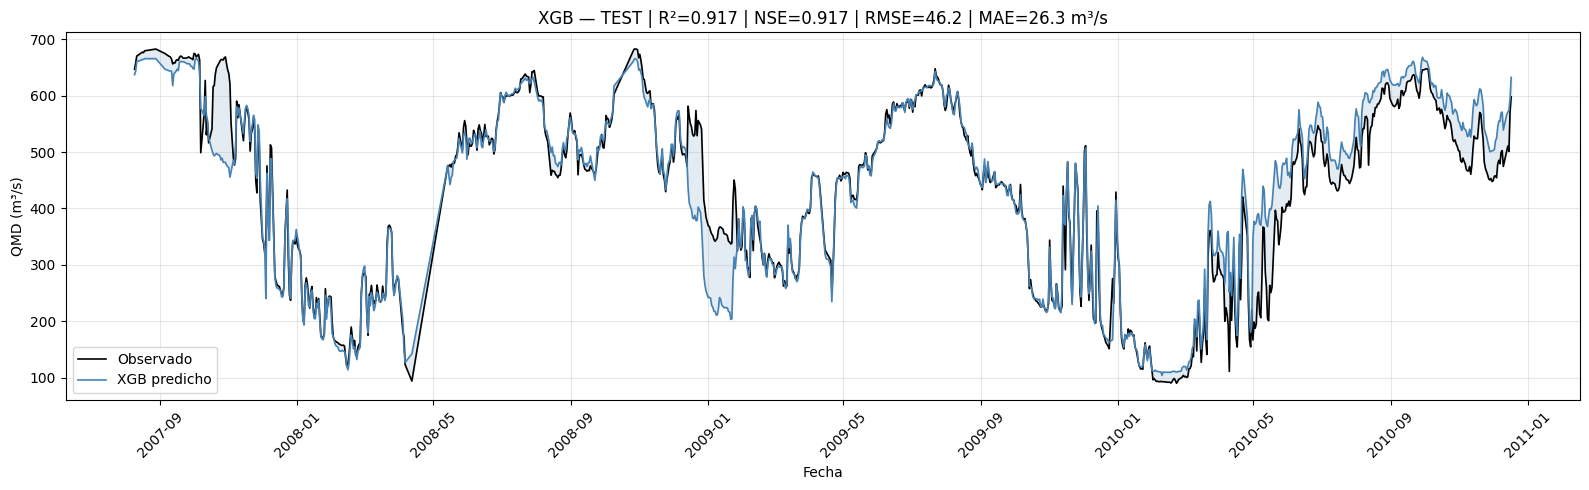

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✔ XGB_evaluacion.xlsx exportado

VARIABLES PARA PREDICCIÓN XGB:
  COTOCA_NIV             -> reutilizada de RF ✅
  COTOCA_QMD             -> reutilizada de RF ✅
  SABANA_NIV             -> NUEVA — debes subir el CSV ⬆️
  SABANA_QMD             -> reutilizada de RF ✅

Sube solo estos archivos: SABANA_NIV.csv


Saving SABANA_NIV.csv to SABANA_NIV.csv
Rango: 2011-01-01 → 2025-12-31 (5479 días)
COTOCA_NIV           huecos: 71
COTOCA_QMD           huecos: 71
SABANA_QMD           huecos: 165
SABANA_NIV           huecos: 192
Días predichos: 5478 / 5479
mín=100.8 | media=378.9 | máx=663.4


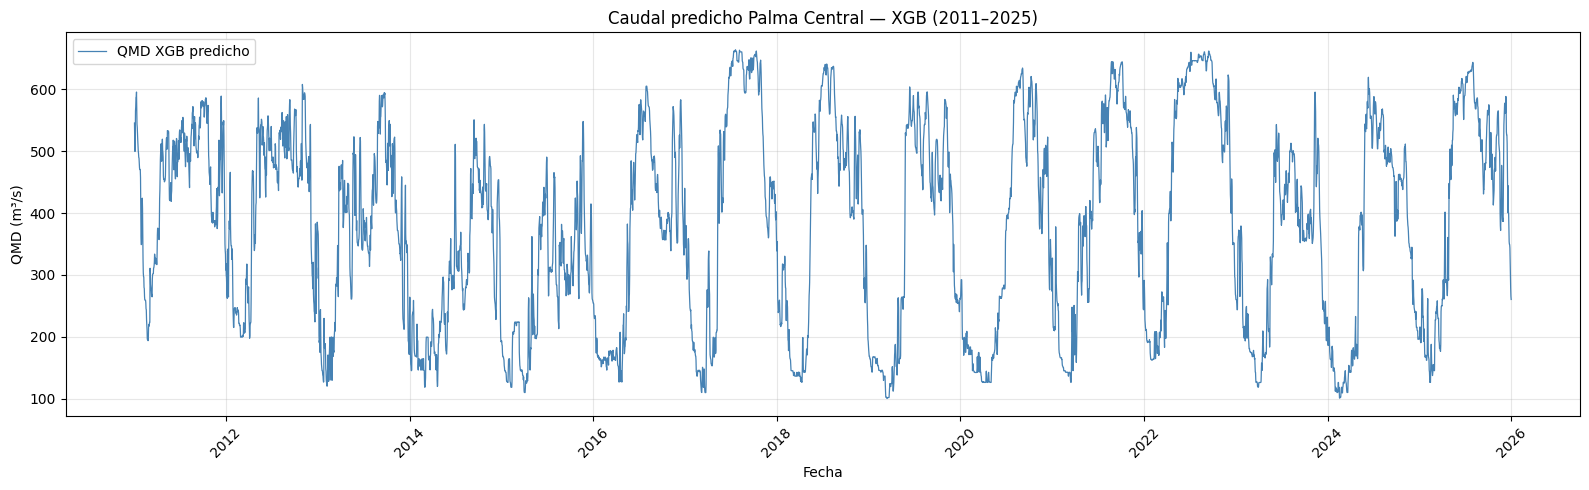

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✔ XGB_prediccion.xlsx exportado


In [ ]:
#============================================================
# CELDA 7 — XGB FINAL + EXPORTACION
# Evaluacion (TRAIN/TEST) y Prediccion (2011-2025)
#============================================================
from xgboost             import XGBRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.inspection  import permutation_importance
from sklearn.metrics     import r2_score, mean_squared_error, mean_absolute_error
from google.colab        import files
import numpy as np, pandas as pd, matplotlib.pyplot as plt, io, re

try: X_train; y_train; X_test; y_test; PREDICTORES; train; test
except NameError: raise NameError("Ejecuta las Celdas 1-3 primero.")

# ── Funciones metricas ───────────────────────────────────────────────────────
def nse(obs, pred):
    obs, pred = np.asarray(obs), np.asarray(pred)
    return 1 - np.sum((obs-pred)**2) / np.sum((obs-obs.mean())**2)

def pbias(obs, pred):
    obs, pred = np.asarray(obs), np.asarray(pred)
    return 100 * np.sum(pred-obs) / np.sum(obs)

def metricas(obs, pred, label):
    r2_ = r2_score(obs, pred)
    print(f"{label}: R²={r2_:.4f} | NSE={nse(obs,pred):.4f} | "
          f"RMSE={np.sqrt(mean_squared_error(obs,pred)):.2f} | "
          f"MAE={mean_absolute_error(obs,pred):.2f} | "
          f"PBIAS={pbias(obs,pred):.2f}%")
    return r2_

# ── Funciones auxiliares de carga e imputacion ───────────────────────────────
def leer_csv(nombre, contenido):
    df = None
    for enc in ["utf-8", "utf-8-sig", "latin1", "cp1252"]:
        for sep in [None, ",", ";", "\t"]:
            try:
                tmp = pd.read_csv(io.BytesIO(contenido), encoding=enc,
                                  sep=sep, engine="python")
                if tmp.shape[1] >= 2: df = tmp.copy(); break
            except: pass
        if df is not None: break
    df.columns = [str(c).strip() for c in df.columns]
    col_f = next((c for c in df.columns if "fecha" in c.lower()
                  or "date" in c.lower()), df.columns[0])
    col_v = next((c for c in df.columns if any(k in c.lower()
                  for k in ["valor","caudal","nivel","flow"])), df.columns[1])
    df = df[[col_f, col_v]].rename(columns={col_f:"Fecha", col_v:"Valor"})
    s  = df["Fecha"].astype(str).str.strip()\
           .str.replace("\ufeff","",regex=False).str.replace("T"," ",regex=False)
    f1 = pd.to_datetime(s, errors="coerce", dayfirst=False)
    f2 = pd.to_datetime(s, errors="coerce", dayfirst=True)
    df["Fecha"] = f2 if f2.isna().sum() < f1.isna().sum() else f1
    df["Valor"] = pd.to_numeric(df["Valor"], errors="coerce")
    df = df.dropna().copy()
    df["Fecha"] = df["Fecha"].dt.normalize()
    return df.groupby("Fecha", as_index=False)["Valor"].mean()

def imputar(s, limite=7):
    # Spline cubico para huecos cortos; lineal para los restantes
    s    = s.copy()
    s_sp = s.interpolate(method="spline", order=3,
                         limit=limite, limit_direction="both")
    s_li = s.interpolate(method="linear", limit_direction="both")
    s[s.isna()] = s_sp[s.isna()].fillna(s_li[s.isna()])
    return s

# ── 1. GridSearch XGB (mismo split y CV que RF) ──────────────────────────────
tscv_xgb = TimeSeriesSplit(n_splits=5, gap=14)
param_grid_xgb = {
    "n_estimators":     [100, 200, 300, 500],
    "learning_rate":    [0.01, 0.02, 0.03, 0.05],
    "max_depth":        [3, 4, 5, 6],
    "subsample":        [0.8],
    "colsample_bytree": [0.8],
}
gs_xgb = GridSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1,
                 objective="reg:squarederror", importance_type="gain"),
    param_grid_xgb, cv=tscv_xgb, scoring="r2", n_jobs=-1, verbose=1)
gs_xgb.fit(X_train, y_train)
BEST_XGB = gs_xgb.best_params_
print(f"BEST_XGB: {BEST_XGB} | R² CV: {gs_xgb.best_score_:.4f}")

# ── 2. Importancia XGB propia en TRAIN (gain, independiente del RF) ──────────
xgb_sel = XGBRegressor(**BEST_XGB, random_state=42, n_jobs=-1,
                        objective="reg:squarederror", importance_type="gain")
xgb_sel.fit(X_train, y_train)

imp_xgb = (pd.DataFrame({"Variable": PREDICTORES,
                          "Importancia_XGB": xgb_sel.feature_importances_})
           .sort_values("Importancia_XGB", ascending=False).reset_index(drop=True))
imp_xgb["Importancia_norm"] = imp_xgb["Importancia_XGB"] / imp_xgb["Importancia_XGB"].sum()
imp_xgb["Acum"] = imp_xgb["Importancia_norm"].cumsum()
print("IMPORTANCIA XGB CALCULADA EN TRAIN:"); display(imp_xgb)

# ── 3. Seleccion con umbral 98% ──────────────────────────────────────────────
UMBRAL_XGB = 0.98
n_xgb    = int(np.searchsorted(imp_xgb["Acum"].values, UMBRAL_XGB)) + 1
n_xgb    = max(n_xgb, 3)
VARS_XGB = imp_xgb["Variable"].head(n_xgb).tolist()
print(f"\nVariables finales XGB ({n_xgb} vars, umbral {UMBRAL_XGB*100:.0f}%): {VARS_XGB}")

# ── 4. Modelo final XGB ───────────────────────────────────────────────────────
xgb_final = XGBRegressor(**BEST_XGB, random_state=42, n_jobs=-1,
                          objective="reg:squarederror", importance_type="gain")
xgb_final.fit(X_train[VARS_XGB], y_train)
yp_train_xgb = xgb_final.predict(X_train[VARS_XGB])
yp_test_xgb  = xgb_final.predict(X_test[VARS_XGB])

# ── 5. Permutation importance en TEST ────────────────────────────────────────
perm_xgb = permutation_importance(
    xgb_final, X_test[VARS_XGB], y_test,
    n_repeats=30, random_state=42, scoring="r2", n_jobs=-1)
perm_xgb_df = (pd.DataFrame({
    "Variable":             VARS_XGB,
    "Perm_importance_TEST": perm_xgb.importances_mean,
    "Perm_std_TEST":        perm_xgb.importances_std
}).sort_values("Perm_importance_TEST", ascending=False).reset_index(drop=True))
print("\nPERMUTATION IMPORTANCE XGB EN TEST:"); display(perm_xgb_df)

# ── 6. Metricas TRAIN / TEST ──────────────────────────────────────────────────
print("\nMÉTRICAS XGB FINAL")
r2_tr_xgb = metricas(y_train, yp_train_xgb, "TRAIN")
r2_te_xgb = metricas(y_test,  yp_test_xgb,  "TEST ")
print(f"GAP R²: {r2_tr_xgb - r2_te_xgb:.4f}")

# ── 7. Grafico TEST ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(test["Fecha"], y_test.values, "k",            lw=1.2, label="Observado")
ax.plot(test["Fecha"], yp_test_xgb, color="steelblue", lw=1.2, label="XGB predicho")
ax.fill_between(test["Fecha"], y_test.values, yp_test_xgb, color="steelblue", alpha=0.15)
ax.set_title(f"XGB — TEST | R²={r2_te_xgb:.3f} | NSE={nse(y_test,yp_test_xgb):.3f} | "
             f"RMSE={np.sqrt(mean_squared_error(y_test,yp_test_xgb)):.1f} | "
             f"MAE={mean_absolute_error(y_test,yp_test_xgb):.1f} m³/s")
ax.set_xlabel("Fecha"); ax.set_ylabel("QMD (m³/s)")
ax.legend(); ax.grid(True, alpha=0.3); ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

# ── 8. Excel XGB_evaluacion.xlsx (TRAIN + TEST) ──────────────────────────────
df_eval_xgb = pd.concat([
    pd.DataFrame({"Fecha": train["Fecha"].values, "Grupo": "TRAIN",
                  "Observado": y_train.values, "Predicho": yp_train_xgb,
                  "Error": yp_train_xgb - y_train.values}),
    pd.DataFrame({"Fecha": test["Fecha"].values,  "Grupo": "TEST",
                  "Observado": y_test.values,  "Predicho": yp_test_xgb,
                  "Error": yp_test_xgb - y_test.values})
], ignore_index=True)
df_eval_xgb.to_excel("XGB_evaluacion.xlsx", index=False)
files.download("XGB_evaluacion.xlsx")
print("✔ XGB_evaluacion.xlsx exportado")

# ── 9. Reutilizar CSVs de RF o pedir solo los nuevos ────────────────────────
VARS_BASE_XGB    = sorted(set(v.replace("_LAG1","") for v in VARS_XGB))
vars_ya_cargadas = [v for v in VARS_BASE_XGB if v in dfs_rf]
vars_faltantes   = [v for v in VARS_BASE_XGB if v not in dfs_rf]

# Informe claro: que se reutiliza y que hay que subir
print("\nVARIABLES PARA PREDICCIÓN XGB:")
for v in VARS_BASE_XGB:
    estado = "reutilizada de RF ✅" if v in dfs_rf else "NUEVA — debes subir el CSV ⬆️"
    print(f"  {v:<22} -> {estado}")

dfs_xgb = {v: dfs_rf[v] for v in vars_ya_cargadas}

if vars_faltantes:
    print(f"\nSube solo estos archivos: {', '.join(v+'.csv' for v in vars_faltantes)}")
    subidos = files.upload()
    subidos_limpios = {
        re.sub(r"\s*\(\d+\)\s*$","",
               n.replace(".csv","").replace(".CSV","")).strip(): c
        for n, c in subidos.items()}
    for v in vars_faltantes:
        dfs_xgb[v] = leer_csv(v, subidos_limpios[v]).rename(columns={"Valor": v})
else:
    print("\nXGB usa las mismas variables que RF. No necesitas subir nada. ✅")

# ── 10. Armar dataframe diario + imputacion ──────────────────────────────────
rango_xgb = pd.date_range(min(d["Fecha"].min() for d in dfs_xgb.values()),
                           max(d["Fecha"].max() for d in dfs_xgb.values()), freq="D")
print(f"Rango: {rango_xgb[0].date()} → {rango_xgb[-1].date()} ({len(rango_xgb)} días)")

df_new_xgb = pd.DataFrame({"Fecha": rango_xgb})
for v, d in dfs_xgb.items():
    s = d.set_index("Fecha")[v].reindex(rango_xgb)
    print(f"{v:<20} huecos: {s.isna().sum()}")
    df_new_xgb[v] = imputar(s).values

for v in VARS_XGB:
    if v.endswith("_LAG1"):
        df_new_xgb[v] = df_new_xgb[v.replace("_LAG1","")].shift(1)

df_pred_xgb = df_new_xgb.dropna(subset=VARS_XGB).reset_index(drop=True)
print(f"Días predichos: {len(df_pred_xgb)} / {len(df_new_xgb)}")

# ── 11. Prediccion 2011-2025 ─────────────────────────────────────────────────
df_pred_xgb["QMD_XGB_PREDICHO"] = xgb_final.predict(df_pred_xgb[VARS_XGB])
print(f"mín={df_pred_xgb['QMD_XGB_PREDICHO'].min():.1f} | "
      f"media={df_pred_xgb['QMD_XGB_PREDICHO'].mean():.1f} | "
      f"máx={df_pred_xgb['QMD_XGB_PREDICHO'].max():.1f}")

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df_pred_xgb["Fecha"], df_pred_xgb["QMD_XGB_PREDICHO"],
        lw=0.9, color="steelblue", label="QMD XGB predicho")
ax.set_title("Caudal predicho Palma Central — XGB (2011–2025)")
ax.set_xlabel("Fecha"); ax.set_ylabel("QMD (m³/s)")
ax.legend(); ax.grid(True, alpha=0.3); ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

# ── 12. Excel XGB_prediccion.xlsx ────────────────────────────────────────────
df_pred_xgb[["Fecha"] + VARS_XGB + ["QMD_XGB_PREDICHO"]].to_excel(
    "XGB_prediccion.xlsx", index=False)
files.download("XGB_prediccion.xlsx")
print("✔ XGB_prediccion.xlsx exportado")

In [ ]:
# ==============================================================================
# PRUEBAS DE SIGNIFICANCIA ESTADÍSTICA - XGBOOST (TEST)
# ==============================================================================
from scipy.stats import wilcoxon

# 1. Generar predicciones en el set de Test
# (Nota: 'xgb_sel' es tu XGB inicial y 'xgb_final' es el modelo con VARS_XGB)
yp_test_completo_xgb = xgb_sel.predict(X_test[PREDICTORES])
yp_test_reducido_xgb = xgb_final.predict(X_test[VARS_XGB])

print("\n" + "="*65)
print("   VALIDACIÓN ESTADÍSTICA COMPLETA - XGBOOST (TEST)")
print("="*65)

# --- CONTRASTE 1: EFECTO DE LA REDUCCIÓN DE VARIABLES ---
stat_x1, p_val_x1 = wilcoxon(yp_test_completo_xgb, yp_test_reducido_xgb)
print(f"[C1] M. Completo vs. M. Reducido (XGB) | p-valor: {p_val_x1:.4e}")
if p_val_x1 > 0.05:
    print(" -> Resultado: NO hay diferencia significativa. Reducción válida.")
else:
    print(" -> Resultado: SÍ hay diferencia. El descarte alteró las predicciones.")

print("-"*65)

# --- CONTRASTE 2: FIDELIDAD HIDROLÓGICA (OBSERVADO VS PREDICHO) ---
stat_x2, p_val_x2 = wilcoxon(y_test, yp_test_reducido_xgb)
print(f"[C2] Caudal Observado vs. M. Reducido (XGB) | p-valor: {p_val_x2:.4e}")
if p_val_x2 > 0.05:
    print(" -> Resultado: NO hay diferencia significativa. Modelo sin sesgo.")
else:
    print(" -> Resultado: SÍ hay diferencia. El modelo presenta sesgos.")
print("="*65 + "\n")
